In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка отображения, чтобы видеть все столбцы
pd.set_option('display.max_columns', None)


In [5]:
print("выгрузка и первичный анализ")

#Загружаем данные
df = pd.read_csv('C:/Users/Redmi/Desktop/practise2026/data/raw/ai_student_impact_dataset (1).csv') 

print(f"\n Данные загружены: {df.shape[0]} строк, {df.shape[1]} столбцов")

выгрузка и первичный анализ

 Данные загружены: 50000 строк, 16 столбцов


In [6]:
# Информация о данных
print("\n--- Информация о столбцах ---")
print(df.info())

# Первые строки
print("\n--- Первые 5 строк ---")
print(df.head())

# Статистика
print("\n--- Статистика числовых признаков ---")
print(df.describe())

# Проверка пропусков
print("\n--- Пропущенные значения ---")
print(df.isnull().sum())


--- Информация о столбцах ---
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semest


--- Распределение Burnout_Risk_Level ---
Burnout_Risk_Level
Medium    21144
Low       16369
High      12487
Name: count, dtype: int64


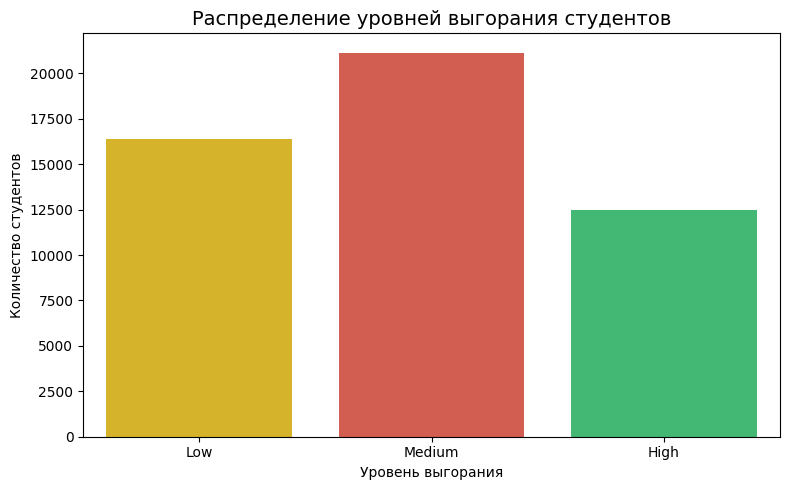

In [7]:
# Распределение целевой переменной
print("\n--- Распределение Burnout_Risk_Level ---")
print(df['Burnout_Risk_Level'].value_counts())

# Базовая визуализация
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df, 
    x='Burnout_Risk_Level', 
    order=['Low', 'Medium', 'High'],
    hue='Burnout_Risk_Level', 
    palette=['#2ecc71', '#f1c40f', '#e74c3c'],
    legend=False  
)
plt.title('Распределение уровней выгорания студентов', fontsize=14)
plt.xlabel('Уровень выгорания')
plt.ylabel('Количество студентов')
plt.tight_layout()
plt.savefig('C:/Users/Redmi/Desktop/practise2026/data/result/burnout_distribution.png', dpi=300)
plt.show()
#testcommit


In [8]:
from sklearn.preprocessing import LabelEncoder

print("ОТБОР ПРИЗНАКОВ И КОДИРОВАНИЕ")


# признаки
features = [
    'Weekly_GenAI_Hours',
    'Primary_Use_Case',
    'Prompt_Engineering_Skill',
    'Tool_Diversity',
    'Traditional_Study_Hours',
    'Perceived_AI_Dependency',
    'Institutional_Policy',
    'Anxiety_Level_During_Exams',
    'Major_Category',
    'Year_of_Study'
]

X = df[features].copy()
y = df['Burnout_Risk_Level'].copy()

print(f" Отобрано {len(features)} признаков")
print(f"   Признаки: {', '.join(features)}")

#кодируем категориальные признаки
print("\n Кодирование категориальных признаков")
encoders = {}

for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le
    print(f" {col} закодирован")

#кодируем целевую переменную
le_y = LabelEncoder()
y_encoded = le_y.fit_transform(y)

print(f"\n Целевая переменная закодирована")
print(f"   Соответствие: {dict(zip(le_y.classes_, le_y.transform(le_y.classes_)))}")

#Проверка
print("\n--- Первые 5 строк после кодирования ---")
print(X.head())


ОТБОР ПРИЗНАКОВ И КОДИРОВАНИЕ
 Отобрано 10 признаков
   Признаки: Weekly_GenAI_Hours, Primary_Use_Case, Prompt_Engineering_Skill, Tool_Diversity, Traditional_Study_Hours, Perceived_AI_Dependency, Institutional_Policy, Anxiety_Level_During_Exams, Major_Category, Year_of_Study

 Кодирование категориальных признаков
 Primary_Use_Case закодирован
 Prompt_Engineering_Skill закодирован
 Institutional_Policy закодирован
 Major_Category закодирован
 Year_of_Study закодирован

 Целевая переменная закодирована
   Соответствие: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

--- Первые 5 строк после кодирования ---
   Weekly_GenAI_Hours  Primary_Use_Case  Prompt_Engineering_Skill  \
0               23.31                 0                         1   
1                1.12                 3                         0   
2               21.26                 4                         1   
3                1.82                 0                         2   
4                9.29    

C:\Users\Redmi\AppData\Local\Temp\ipykernel_21248\2522865454.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include=['object']).columns:


ШАГ 1.3: ВИЗУАЛИЗАЦИЯ СВЯЗЕЙ ПРИЗНАКОВ С ВЫГОРАНИЕМ


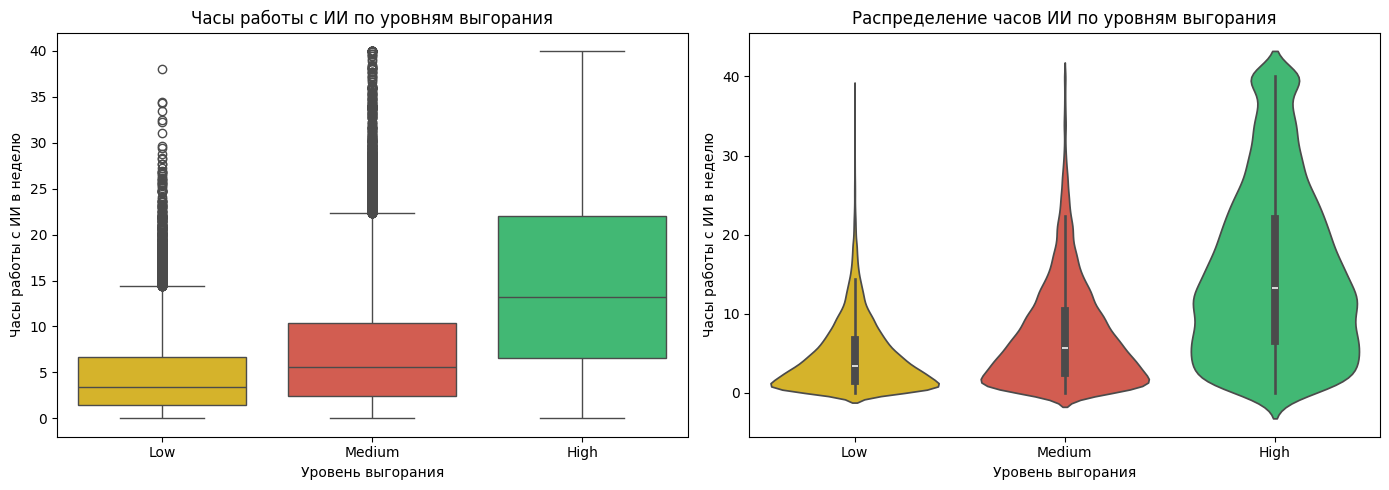

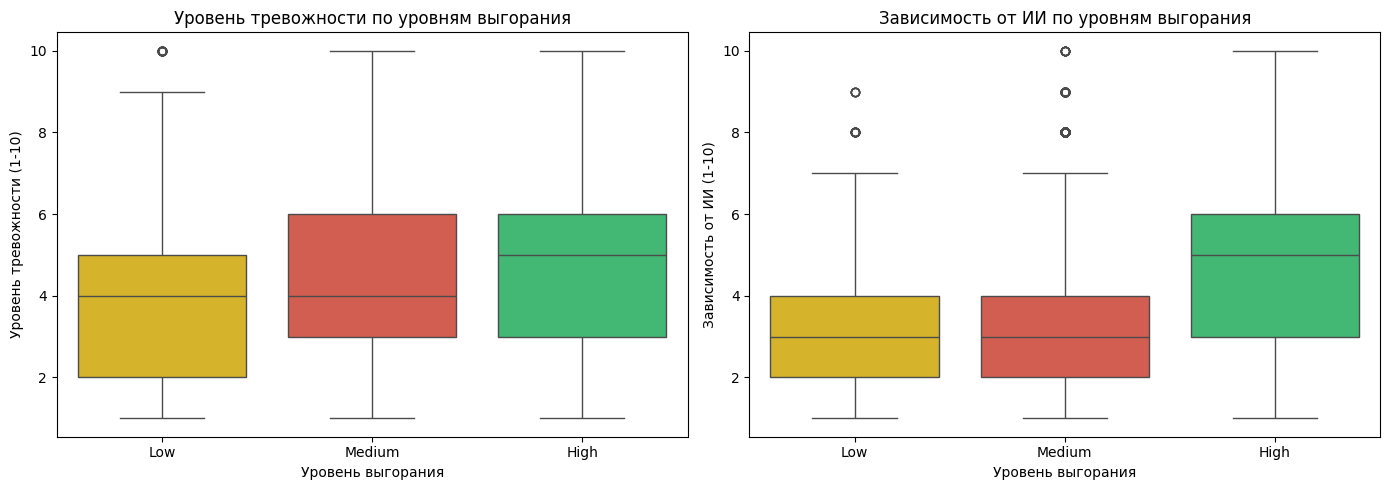

In [10]:

print("ШАГ 1.3: ВИЗУАЛИЗАЦИЯ СВЯЗЕЙ ПРИЗНАКОВ С ВЫГОРАНИЕМ")

df_viz = X.copy()
df_viz['Burnout'] = y # метки Low/Medium/High

# График 1: Часы с ИИ vs Выгорание 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    x='Burnout', 
    y='Weekly_GenAI_Hours', 
    data=df_viz,
    order=['Low', 'Medium', 'High'],
    hue='Burnout',
    palette=['#2ecc71', '#f1c40f', '#e74c3c'],
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Часы работы с ИИ по уровням выгорания', fontsize=12)
axes[0].set_xlabel('Уровень выгорания')
axes[0].set_ylabel('Часы работы с ИИ в неделю')

sns.violinplot(
    x='Burnout', 
    y='Weekly_GenAI_Hours', 
    data=df_viz,
    order=['Low', 'Medium', 'High'],
    hue='Burnout',
    palette=['#2ecc71', '#f1c40f', '#e74c3c'],
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Распределение часов ИИ по уровням выгорания', fontsize=12)
axes[1].set_xlabel('Уровень выгорания')
axes[1].set_ylabel('Часы работы с ИИ в неделю')

plt.tight_layout()
plt.savefig('C:/Users/Redmi/Desktop/practise2026/data/result/ai_hours_vs_burnout.png', dpi=300)
plt.show()

# График 2: Тревожность и Зависимость от ИИ vs Выгорание
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Тревожность
sns.boxplot(
    x='Burnout', 
    y='Anxiety_Level_During_Exams', 
    data=df_viz,
    order=['Low', 'Medium', 'High'],
    hue='Burnout',
    palette=['#2ecc71', '#f1c40f', '#e74c3c'],
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Уровень тревожности по уровням выгорания', fontsize=12)
axes[0].set_xlabel('Уровень выгорания')
axes[0].set_ylabel('Уровень тревожности (1-10)')

# Зависимость от ИИ
sns.boxplot(
    x='Burnout', 
    y='Perceived_AI_Dependency', 
    data=df_viz,
    order=['Low', 'Medium', 'High'],
    hue='Burnout',
    palette=['#2ecc71', '#f1c40f', '#e74c3c'],
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Зависимость от ИИ по уровням выгорания', fontsize=12)
axes[1].set_xlabel('Уровень выгорания')
axes[1].set_ylabel('Зависимость от ИИ (1-10)')

plt.tight_layout()
plt.savefig('C:/Users/Redmi/Desktop/practise2026/data/result/anxiety_dependency_vs_burnout.png', dpi=300)
plt.show()
